# Part 2: News Classification Using Deep Learning

This notebook investigates multi-class news classification using the **AG News Classification Dataset**.

Two deep learning approaches are developed and compared:

1. a **Bidirectional LSTM (BiLSTM)** with a trainable embedding layer; and
2. **DistilBERT**, a pretrained transformer fine-tuned for the four AG News categories.

The provided training data is divided into training and validation sets for model development, while the official AG News test set is kept separate until the final evaluation.

The models are compared using accuracy, loss, precision, recall, F1-score, confusion matrices, class-level error patterns and model complexity. This allows the final discussion to consider not only which model performs better, but also where the models make mistakes and the trade-off between predictive performance and model size.


## 1. Import Libraries

The required libraries are imported for data handling, visualisation, model development and evaluation. A fixed random seed is used to make the data split and model training as reproducible as possible.


In [ ]:
# Import the libraries and set a fixed random seed for reproducible results.
import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf


# Set random seed for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


## 2. Load the Dataset

The AG News dataset contains separate training and test CSV files. The training file contains 120,000 labelled news articles, while the official test file contains 7,600 articles.

Each article contains a class index, title and description. The dataset is loaded from Google Drive for this notebook run.


In [ ]:
# Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define the paths to the training and test datasets
train_path = "/content/drive/MyDrive/IT3381_ADL/ADL_Assignment_Part2_Data/train.csv"
test_path = "/content/drive/MyDrive/IT3381_ADL/ADL_Assignment_Part2_Data/test.csv"

# Load the CSV files
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

Training dataset shape: (120000, 3)
Test dataset shape: (7600, 3)


In [ ]:
# Preview the loaded datasets
print("Training Dataset:")
display(train_df.head())

print("\nTest Dataset:")
display(test_df.head())

Training Dataset:


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."



Test Dataset:


,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


## 3. Exploratory Data Analysis

Before preprocessing and model training, exploratory analysis is carried out to understand the structure of the AG News dataset. The focus is on the dataset size, available columns, class distribution and the general content of the news articles.

### 3.1 Inspect Dataset Structure and Classes

The structure of the training and test datasets is examined to identify the available columns, number of samples and the four news categories used for classification.

In [ ]:
# Display basic information about the training dataset.
print("Training dataset shape:", train_df.shape)
print("Test dataset shape:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nTraining dataset information:")
train_df.info()

Training dataset shape: (120000, 3)
Test dataset shape: (7600, 3)

Columns:
['Class Index', 'Title', 'Description']

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [ ]:
# Define the class labels used in the AG News dataset.
class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

print("Number of classes:", len(class_names))

print("\nClasses:")
for class_index, class_name in class_names.items():
    print(f"{class_index}: {class_name}")

Number of classes: 4

Classes:
1: World
2: Sports
3: Business
4: Sci/Tech


In [ ]:
# Count the number of news articles in each class.
class_counts = (
    train_df["Class Index"]
    .value_counts()
    .sort_index()
)

counts_df = pd.DataFrame({
    "Class Index": class_counts.index,
    "Class": [class_names[i] for i in class_counts.index],
    "Number of Articles": class_counts.values
})

print("Total number of training articles:", len(train_df))

counts_df

Total number of training articles: 120000


,Class Index,Class,Number of Articles
0,1,World,30000
1,2,Sports,30000
2,3,Business,30000
3,4,Sci/Tech,30000


The training dataset contains **120,000 news articles** across four categories: World, Sports, Business and Sci/Tech. Each class contains exactly **30,000 articles**.

The equal class counts mean that the dataset is already balanced, so the models are not exposed to one category more frequently than another during training. This also means that class weighting is not required.


### 3.2 Analyse Class Distribution

The class counts are visualised using a bar chart to confirm whether the four news categories are evenly represented in the training dataset.

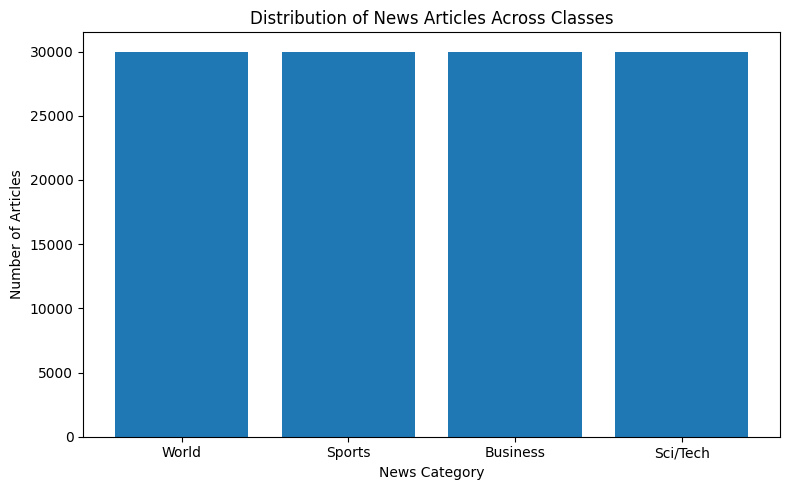

In [ ]:
# Plot the number of news articles in each category.
plt.figure(figsize=(8, 5))

plt.bar(
    counts_df["Class"],
    counts_df["Number of Articles"]
)

plt.title("Distribution of News Articles Across Classes")
plt.xlabel("News Category")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()

The bar chart confirms that all four classes contain the same number of training samples.

Since the dataset is perfectly balanced at this stage, later evaluation can also use macro-averaged metrics without one class having more influence simply because it contains more examples.


### 3.3 Display Sample News Articles

Sample news articles from each category are displayed to verify the class labels and gain an initial understanding of the language and topics associated with each news category.

In [ ]:
# Display one sample news article from each category.
for class_index, class_name in class_names.items():

    sample = train_df[
        train_df["Class Index"] == class_index
    ].sample(1, random_state=SEED)

    print("=" * 80)
    print(f"Class: {class_name}")
    print(f"Title: {sample['Title'].iloc[0]}")
    print(f"Description: {sample['Description'].iloc[0]}")
    print()

Class: World
Title: Explosion Rocks Baghdad Neighborhood
Description: BAGHDAD, Iraq, August 24 -- A car bomb exploded near the gate of a US-funded Iraqi television network in Baghdad on Tuesday, killing at least two people and wounding two others, authorities and witnesses said.

Class: Sports
Title: Second Andre win in a row boosts US gold medal hopes
Description: Andre Dirrell, fighting with a tattoo of his grandfather #39;s face on his back, assured the United States of at least two boxing medals Wednesday by narrowly beating Cuba #39;s Yordani Despaigne to advance to the Olympic middleweight semifinals.

Class: Business
Title: US house sales fall in July
Description: Sales of non-new houses in the US fell last month but still exceeded analyst forecasts.

Class: Sci/Tech
Title: Gartner optimistic about chip numbers
Description: But that optimism isn #39;t matched by Infineon, which said that while the market worldwide remains buoyant, the US is a special case and cautioned that grow

The sample articles show clear differences between the four topics. Sports articles often contain names of athletes, teams and competitions, while Business articles commonly refer to companies, markets and financial activity.

However, the categories are not completely separated by vocabulary. For example, technology companies can appear in both Business and Sci/Tech articles, while international sporting events may also contain terms associated with countries and politics. This makes context important rather than relying only on individual keywords.


## 4. Data Pre-processing

The AG News data is checked and prepared before either model is trained.

The main steps are:

- checking for missing values;
- combining each title and description into one text input;
- removing backslash formatting artifacts;
- encoding the four class labels;
- creating stratified training and validation sets;
- verifying the class distribution after splitting; and
- inspecting article lengths before choosing the sequence limits used by the models.

Only limited manual text cleaning is applied. This keeps the original wording and word order largely intact while allowing each model to use the tokenization method designed for its architecture.


### 4.1 Why Minimal Manual Text Pre-processing is Used

Extensive manual text processing is not required for the two deep learning models used in this task.

For the BiLSTM, Keras `TextVectorization` standardises the text, splits it into tokens and converts those tokens into integer indices. The indices are then passed to a trainable embedding layer, allowing useful word representations to be learned directly from the training data.

Stop-word removal, stemming and lemmatisation are not applied manually because they could remove or alter words that contribute useful sequence or contextual information.

DistilBERT uses its own pretrained WordPiece tokenizer, so its text should not be forced through the BiLSTM vectorization pipeline.

The dataset-level cleaning is therefore kept limited to issues that are clearly formatting-related, while model-specific tokenization is handled separately.


### 4.2 Check for Missing Values

The training and test datasets are checked for missing values before further preprocessing.

Each sample requires a class label, title and description. Missing values could result in incomplete inputs or labels during model training.

In [ ]:
# Check for missing values.
print("Training dataset:")
print(train_df.isnull().sum())

print("\nTest dataset:")
print(test_df.isnull().sum())

Training dataset:
Class Index    0
Title          0
Description    0
dtype: int64

Test dataset:
Class Index    0
Title          0
Description    0
dtype: int64


No missing values are present in the training or test dataset for the class index, title or description fields.

Therefore, no rows need to be removed or filled, and all **120,000 training articles** and **7,600 test articles** can be retained.


### 4.3 Combine the Title and Description

Each news article contains both a title and a description. The title gives a short summary of the article, while the description provides additional information about the news story.

Both fields are combined into a single `Text` feature so that the models can learn from all the available textual information when predicting the news category.

In [ ]:
# Combine the title and description before cleaning.
train_df["Original_Text"] = (
    train_df["Title"].astype(str)
    + " "
    + train_df["Description"].astype(str)
)

test_df["Original_Text"] = (
    test_df["Title"].astype(str)
    + " "
    + test_df["Description"].astype(str)
)

# Remove backslash formatting artifacts.
train_df["Text"] = train_df["Original_Text"].str.replace(
    "\\",
    " ",
    regex=False
)

test_df["Text"] = test_df["Original_Text"].str.replace(
    "\\",
    " ",
    regex=False
)

In [ ]:
# Find examples where the text changed after cleaning.
changed_samples = train_df[
    train_df["Original_Text"] != train_df["Text"]
]

print("Number of training articles affected:", len(changed_samples))

# Display a few before-and-after examples.
for i, (_, row) in enumerate(changed_samples.head(3).iterrows()):
    print(f"\nSample {i + 1}")

    print("\nBefore cleaning:")
    print(row["Original_Text"])

    print("\nAfter cleaning:")
    print(row["Text"])

    print("-" * 100)

Number of training articles affected: 13146

Sample 1

Before cleaning:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

After cleaning:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling band of ultra-cynics, are seeing green again.
----------------------------------------------------------------------------------------------------

Sample 2

Before cleaning:
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

After cleaning:
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group, which has a reputation for making well-timed and occasionally controversial plays in the defense industry, 

The comparison shows that backslash characters appear inside a noticeable number of articles as formatting artifacts. In total, **13,146 training articles** are affected.

Replacing each backslash with a space prevents neighbouring words from being joined incorrectly during tokenization. For example, `dwindling\band` becomes `dwindling band`.

No aggressive cleaning is applied beyond this formatting issue, so the original wording and sentence structure remain available to the models.


### 4.4 Encode the Class Labels

The original AG News dataset represents the four news categories using class indices from 1 to 4.

For model training, these labels are converted to values from 0 to 3 so that they can be used directly for four-class classification.

The encoded classes are:

- 0 = World
- 1 = Sports
- 2 = Business
- 3 = Sci/Tech

In [ ]:
# Define the four class names.
CLASS_NAMES = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

# Convert labels from 1-4 to 0-3.
train_df["Label"] = train_df["Class Index"] - 1
test_df["Label"] = test_df["Class Index"] - 1

# Display the label mapping.
for i, class_name in enumerate(CLASS_NAMES):
    print(f"{i}: {class_name}")

0: World
1: Sports
2: Business
3: Sci/Tech


In [ ]:
# Check the number of samples for each encoded label.
print(train_df["Label"].value_counts().sort_index())

Label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


After encoding the labels from 1–4 to 0–3, each class still contains exactly **30,000 training articles**.

The encoding therefore changes only the numerical label representation and does not alter the class distribution.


### 4.5 Create Training and Validation Sets

The provided training dataset is divided into training and validation sets using an 80:20 split.

This produces a training set for learning the model parameters and a separate validation set for monitoring generalisation and making model-selection decisions.

Stratified sampling is used so that World, Sports, Business and Sci/Tech remain equally represented in both subsets.

The official `test.csv` file is not used for training, validation or model selection and is reserved for the final evaluation.


In [ ]:
# Split train.csv into 80% training and 20% validation.
train_data, val_data = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["Label"]
)

# Reset the dataframe indices.
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(test_df))

Training samples: 96000
Validation samples: 24000
Test samples: 7600


### 4.6 Verify the Class Distribution

The class distributions of the training, validation and test datasets are checked after splitting.

This confirms that stratified sampling has maintained an even representation of the four news categories and helps determine whether techniques such as class weighting are required.

In [ ]:
# Check the class distribution of each dataset.
print("Training set:")
print(train_data["Label"].value_counts().sort_index())

print("\nValidation set:")
print(val_data["Label"].value_counts().sort_index())

print("\nTest set:")
print(test_df["Label"].value_counts().sort_index())

Training set:
Label
0    24000
1    24000
2    24000
3    24000
Name: count, dtype: int64

Validation set:
Label
0    6000
1    6000
2    6000
3    6000
Name: count, dtype: int64

Test set:
Label
0    1900
1    1900
2    1900
3    1900
Name: count, dtype: int64


The split produces **96,000 training articles**, **24,000 validation articles** and **7,600 test articles**.

Each class contains 24,000 training samples, 6,000 validation samples and 1,900 test samples. The distribution therefore remains perfectly balanced after splitting, so class weighting is unnecessary.


### 4.7 Inspect Article Lengths

Article lengths are inspected before the fixed sequence limits are chosen.

The BiLSTM requires sequences in a batch to have a consistent length, while transformer self-attention becomes more memory-intensive as the sequence grows. Looking at the actual article-length distribution makes it possible to choose limits that cover almost all articles without using unnecessarily long sequences.


In [ ]:
# Inspect the number of whitespace-separated words in the training text.
word_counts = train_data["Text"].str.split().str.len()

length_summary = pd.DataFrame({
    "Statistic": [
        "Median",
        "90th percentile",
        "95th percentile",
        "99th percentile",
        "Maximum"
    ],
    "Word Count": [
        word_counts.median(),
        word_counts.quantile(0.90),
        word_counts.quantile(0.95),
        word_counts.quantile(0.99),
        word_counts.max()
    ]
})

display(length_summary)

print(
    "Articles with <= 128 words:",
    f"{(word_counts <= 128).mean() * 100:.2f}%"
)

print(
    "Articles with <= 200 words:",
    f"{(word_counts <= 200).mean() * 100:.2f}%"
)


,Statistic,Word Count
0,Median,37.0
1,90th percentile,48.0
2,95th percentile,53.0
3,99th percentile,70.0
4,Maximum,171.0


Articles with <= 128 words: 99.95%
Articles with <= 200 words: 100.00%


The articles are generally short. The median article contains **37 words**, the 95th percentile is **53 words**, and the 99th percentile is only **70 words**. The longest article contains **171 words**.

A sequence length of **200 tokens** is therefore generous for the BiLSTM and is large enough to cover all articles based on the whitespace word-count check.

DistilBERT uses a shorter maximum of **128 tokens** to reduce memory and computation. About **99.95% of articles contain 128 words or fewer**, so this limit still covers nearly the entire dataset by word count. DistilBERT uses subword tokenization, so its exact token counts can be slightly higher than the whitespace word counts shown here.


### 4.8 Model-Specific Tokenization

The two models require different numerical representations of the text.

For the **BiLSTM**, Keras `TextVectorization` standardises the text, splits it into tokens and maps the tokens to integer indices. These indices are then passed into a trainable embedding layer.

For **DistilBERT**, the BiLSTM vectorizer is not used. DistilBERT has its own pretrained WordPiece tokenizer, which creates the `input_ids` and `attention_mask` expected by the transformer.

Keeping the two tokenization pipelines separate ensures that each model receives the input representation it was designed to use.


## 5. Model 1 - Bidirectional LSTM Development

The first model is a Bidirectional LSTM with a trainable embedding layer.

A baseline BiLSTM is trained first so that its learning behaviour can be observed directly. A second, more regularised version is then tested using Dropout, a ReLU Dense layer and validation-based callbacks.

The two versions are compared using validation loss before the final BiLSTM is selected. The official test set remains untouched during this development process.


### 5.1 Prepare the TensorFlow Datasets

The training and validation text are converted into TensorFlow datasets.

A batch size of **128** is used for the BiLSTM. The training data is shuffled, while the validation data is kept in a fixed order. Caching and prefetching are used to reduce input-pipeline overhead during training.


In [ ]:
# Define the batch size.
BILSTM_BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

# Create the training dataset.
train_bilstm_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_data["Text"].values,
        train_data["Label"].values
    )
)

train_bilstm_ds = (
    train_bilstm_ds
    .cache()
    .shuffle(
        buffer_size=len(train_data),
        seed=SEED
    )
    .batch(BILSTM_BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

# Create the validation dataset.
val_bilstm_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_data["Text"].values,
        val_data["Label"].values
    )
)

val_bilstm_ds = (
    val_bilstm_ds
    .cache()
    .batch(BILSTM_BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

### 5.2 Create the Text Vectorization Layer

The Keras `TextVectorization` layer is adapted using **training text only**.

The vocabulary is limited to the 10,000 most frequent tokens and every article is represented using a maximum sequence length of 200 tokens. Shorter sequences are padded, while longer sequences are truncated.

Adapting the vocabulary only on the training set prevents information from the validation or test data from influencing the learned vocabulary.


In [ ]:
# Define the text vectorization settings.
VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_SEQUENCE_LENGTH
)

# Use only the training text to build the vocabulary.
text_ds = train_bilstm_ds.map(
    lambda text, label: text
)

vectorize_layer.adapt(text_ds)

print(
    "Vocabulary size:",
    len(vectorize_layer.get_vocabulary())
)

Vocabulary size: 10000


### 5.3 Inspect the Vectorized Text

One training article is passed through the vectorization layer to verify that the raw text is converted into integer token indices before it reaches the embedding layer.


In [ ]:
# Inspect how one article is converted into token indices.
sample_text = train_data["Text"].iloc[0]

sample_vector = vectorize_layer(
    tf.constant([sample_text])
)

print("Original text:")
print(sample_text)

print("\nFirst 30 token indices:")
print(sample_vector[0][:30].numpy())

Original text:
Clijsters Unsure About Latest Injury, Says Hewitt  TOKYO (Reuters) - Belgian Kim Clijsters is unsure about the  exact nature of the injury that has prematurely ended her  season, her fiance Lleyton Hewitt said on Wednesday.

First 30 token indices:
[5341    1   57  282  877   73 1810  411   24 4466 3251 5341   16    1
   57    2 9886 4596    5    2  877   11   22    1  759  242  107  242
    1 3456]


### 5.4 Baseline BiLSTM Architecture

The baseline model uses the following processing flow:

`TextVectorization` → `Embedding` → `Bidirectional LSTM` → `Dense` → `Softmax`

The embedding layer has 128 dimensions and is learned directly from the AG News training data. The Bidirectional LSTM contains 64 units in each direction and produces a 128-value representation before the Dense classification layers.

The model contains **1,387,332 trainable parameters**, with most of them coming from the 10,000 × 128 trainable embedding matrix.

This model is used as the starting point so that its training and validation behaviour can be examined before adding further regularisation.


In [ ]:
# Build the baseline BiLSTM.
EMBEDDING_DIM = 128

tf.keras.utils.set_random_seed(SEED)

bilstm_baseline = tf.keras.Sequential([
    tf.keras.Input(
        shape=(),
        dtype=tf.string
    ),

    vectorize_layer,

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="baseline_embedding"
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),

    tf.keras.layers.Dense(64),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
], name="BiLSTM_Baseline")

bilstm_baseline.summary()


Model: "BiLSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ baseline_embedding (Embedding)  │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,332 (5.29 MB)

 Trainable params: 1,387,332 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

### 5.5 Train the Baseline BiLSTM

The baseline is trained for 10 epochs using Adam and sparse categorical crossentropy.

A checkpoint saves the weights from the epoch with the lowest validation loss. This allows the full training behaviour to be observed while still preserving the best-performing baseline configuration for later comparison.

Only the training and validation sets are used at this stage.


In [ ]:
# Compile the baseline BiLSTM.
bilstm_baseline.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_weights_path = "bilstm_baseline_best.weights.h5"

baseline_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    baseline_weights_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

bilstm_baseline_history = bilstm_baseline.fit(
    train_bilstm_ds,
    validation_data=val_bilstm_ds,
    epochs=10,
    callbacks=[baseline_checkpoint],
    verbose=1
)

baseline_best_val_loss = min(
    bilstm_baseline_history.history["val_loss"]
)

baseline_best_val_accuracy = max(
    bilstm_baseline_history.history["val_accuracy"]
)

baseline_best_epoch = (
    int(np.argmin(
        bilstm_baseline_history.history["val_loss"]
    ))
    + 1
)

print("Best baseline epoch by validation loss:", baseline_best_epoch)
print("Best baseline validation loss:", round(baseline_best_val_loss, 4))
print("Best baseline validation accuracy:", round(baseline_best_val_accuracy, 4))


Epoch 1/10
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8013 - loss: 0.5044
Epoch 1: val_loss improved from None to 0.26076, saving model to bilstm_baseline_best.weights.h5

Epoch 1: finished saving model to bilstm_baseline_best.weights.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8774 - loss: 0.3450 - val_accuracy: 0.9117 - val_loss: 0.2608
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9311 - loss: 0.1975
Epoch 2: val_loss improved from 0.26076 to 0.24539, saving model to bilstm_baseline_best.weights.h5

Epoch 2: finished saving model to bilstm_baseline_best.weights.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9279 - loss: 0.2065 - val_accuracy: 0.9158 - val_loss: 0.2454
Epoch 3/10
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9468 - loss: 0.1515
Epoch 3: val_loss did not improve from 0.24539
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9433 - loss: 0.1601 - val_accuracy: 0.9143 - val_loss: 0.2613
Epoc

### 5.6 Baseline Training Behaviour

The training and validation curves are examined to determine when the model stops improving on unseen validation data.

The checkpointed validation loss is used to identify the strongest baseline epoch rather than assuming that the final training epoch is the best one.


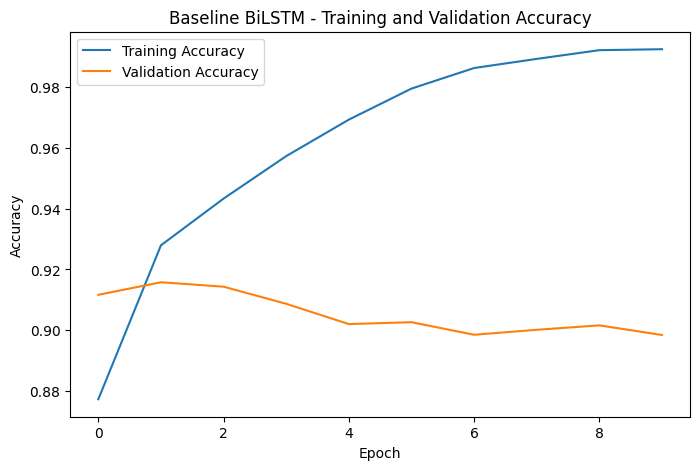

In [ ]:
# Plot baseline training and validation accuracy.
plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_baseline_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    bilstm_baseline_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline BiLSTM - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


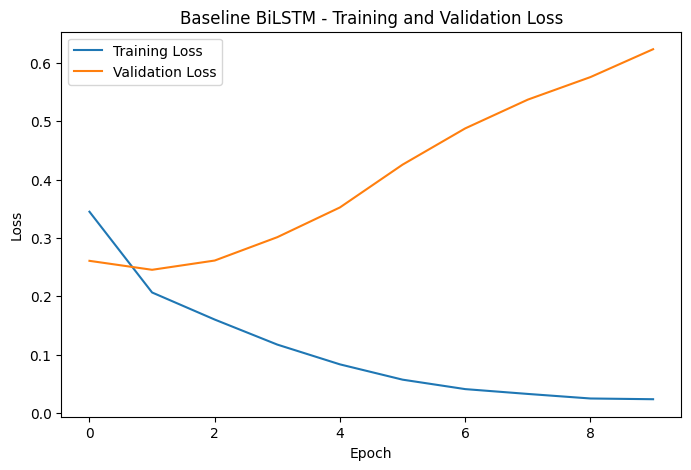

In [ ]:
# Plot baseline training and validation loss.
plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    bilstm_baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline BiLSTM - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


The baseline learns the training data quickly, but the curves show clear overfitting after the first few epochs.

Validation loss improves from **0.2608 in epoch 1 to its best value of 0.2454 in epoch 2**, while validation accuracy reaches its best value of **91.58%**. After epoch 2, training accuracy continues to rise from 92.79% to **99.24% by epoch 10**, but validation accuracy gradually falls to **89.85%**.

The loss curve makes the same pattern even clearer. Training loss falls to **0.0235**, while validation loss increases steadily to **0.6236** by the final epoch.

The best baseline is therefore the checkpoint from **epoch 2**, not the final epoch. The widening train-validation gap motivates testing a more regularised BiLSTM rather than simply training for longer.


### 5.7 Improved BiLSTM Architecture and Training Strategy

The second BiLSTM keeps the same 10,000-word vocabulary, 128-dimensional embedding and 64-unit Bidirectional LSTM so that the comparison remains focused.

Three changes are introduced:

- Dropout is added after the BiLSTM and Dense layer to reduce reliance on individual activations.
- The 64-neuron Dense layer uses ReLU activation to introduce an additional non-linear transformation.
- `EarlyStopping` and `ReduceLROnPlateau` monitor validation loss so that training can stop or slow down when generalisation stops improving.

These changes do not increase the parameter count, so the model remains at **1,387,332 parameters**.

The model is allowed to train for up to 10 epochs, but the callbacks determine whether training should end earlier and restore the best validation weights.


In [ ]:
# Build the improved BiLSTM.
tf.keras.utils.set_random_seed(SEED)

bilstm_model = tf.keras.Sequential([
    tf.keras.Input(
        shape=(),
        dtype=tf.string
    ),

    vectorize_layer,

    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="improved_embedding"
    ),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64)
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
], name="BiLSTM_Improved")

bilstm_model.summary()


Model: "BiLSTM_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ improved_embedding (Embedding)  │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,332 (5.29 MB)

 Trainable params: 1,387,332 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the improved BiLSTM.
bilstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1
    )
]

bilstm_history = bilstm_model.fit(
    train_bilstm_ds,
    validation_data=val_bilstm_ds,
    epochs=10,
    callbacks=bilstm_callbacks,
    verbose=1
)

improved_best_val_loss = min(
    bilstm_history.history["val_loss"]
)

improved_best_val_accuracy = max(
    bilstm_history.history["val_accuracy"]
)

improved_best_epoch = (
    int(np.argmin(
        bilstm_history.history["val_loss"]
    ))
    + 1
)

print("Best improved epoch by validation loss:", improved_best_epoch)
print("Best improved validation loss:", round(improved_best_val_loss, 4))
print("Best improved validation accuracy:", round(improved_best_val_accuracy, 4))


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.8671 - loss: 0.3796 - val_accuracy: 0.9157 - val_loss: 0.2533 - learning_rate: 0.0010
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9259 - loss: 0.2254 - val_accuracy: 0.9157 - val_loss: 0.2523 - learning_rate: 0.0010
Epoch 3/10
748/750 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9385 - loss: 0.1771
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9366 - loss: 0.1829 - val_accuracy: 0.9138 - val_loss: 0.2681 - learning_rate: 0.0010
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9555 - loss: 0.1209
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.9543 - loss: 0.1231 - val_accuracy: 0.9135 - val_loss: 0.3030 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epo

### 5.8 Improved BiLSTM Training Behaviour


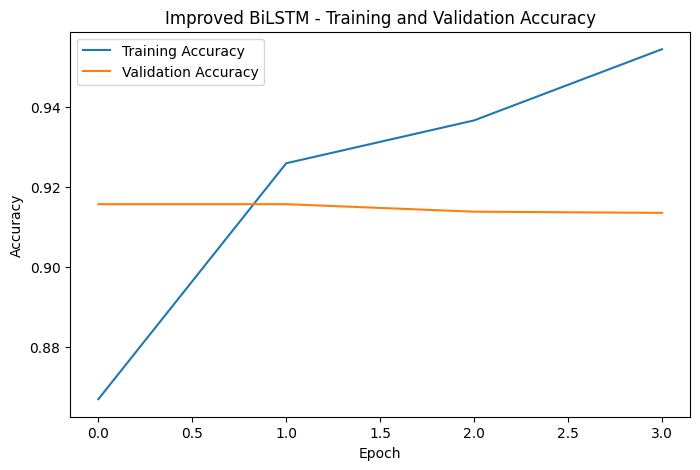

In [ ]:
# Plot improved BiLSTM accuracy.
plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    bilstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Improved BiLSTM - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


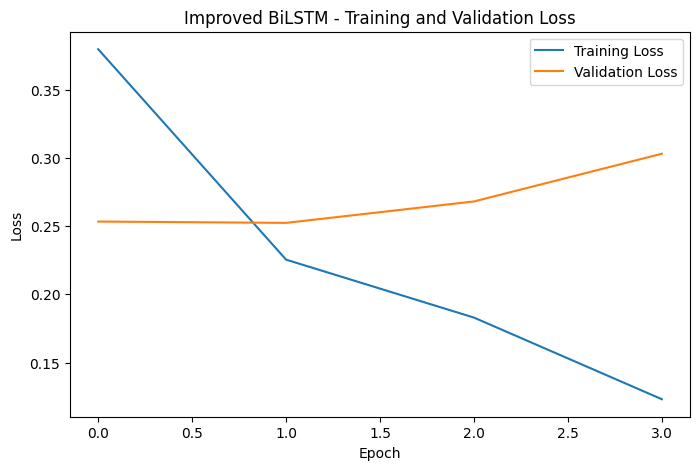

In [ ]:
# Plot improved BiLSTM loss.
plt.figure(figsize=(8, 5))

plt.plot(
    bilstm_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    bilstm_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Improved BiLSTM - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


The regularised BiLSTM reaches its best validation result in **epoch 2**, with **91.57% validation accuracy** and a validation loss of **0.2523**.

Training accuracy continues to improve after this point, but validation loss rises to 0.2681 in epoch 3 and 0.3030 in epoch 4. `ReduceLROnPlateau` lowers the learning rate twice, and `EarlyStopping` ends training after epoch 4 before the gap can continue growing.

The callbacks therefore control the overfitting behaviour as intended. However, the best validation result is not better than the baseline, so the final model should be chosen from the actual validation comparison rather than from the model name alone.


### 5.9 Baseline vs Improved BiLSTM

The two BiLSTM configurations are compared using validation performance only.

Validation loss is used as the main selection criterion because it reflects both prediction correctness and confidence. This decision is made before the test set is used.


In [ ]:
# Compare the two BiLSTM configurations.
bilstm_development_df = pd.DataFrame({
    "Model": [
        "Baseline BiLSTM",
        "Improved BiLSTM"
    ],
    "Parameters": [
        bilstm_baseline.count_params(),
        bilstm_model.count_params()
    ],
    "Best Validation Accuracy": [
        baseline_best_val_accuracy,
        improved_best_val_accuracy
    ],
    "Best Validation Loss": [
        baseline_best_val_loss,
        improved_best_val_loss
    ]
})

display(
    bilstm_development_df.round(4)
)

# Select the configuration with the lower validation loss.
if improved_best_val_loss <= baseline_best_val_loss:
    selected_bilstm_model = bilstm_model
    selected_bilstm_name = "Improved BiLSTM"
    selected_bilstm_val_loss = improved_best_val_loss
    selected_bilstm_val_accuracy = improved_best_val_accuracy
else:
    bilstm_baseline.load_weights(
        baseline_weights_path
    )
    selected_bilstm_model = bilstm_baseline
    selected_bilstm_name = "Baseline BiLSTM"
    selected_bilstm_val_loss = baseline_best_val_loss
    selected_bilstm_val_accuracy = baseline_best_val_accuracy

print("Selected BiLSTM:", selected_bilstm_name)
print(
    "Selected validation loss:",
    round(selected_bilstm_val_loss, 4)
)
print(
    "Selected best validation accuracy:",
    round(selected_bilstm_val_accuracy, 4)
)


,Model,Parameters,Best Validation Accuracy,Best Validation Loss
0,Baseline BiLSTM,1387332,0.9158,0.2454
1,Improved BiLSTM,1387332,0.9157,0.2523


Selected BiLSTM: Baseline BiLSTM
Selected validation loss: 0.2454
Selected best validation accuracy: 0.9158


The validation comparison selects the **Baseline BiLSTM**.

Its best validation loss is **0.2454**, compared with **0.2523** for the more regularised version. Best validation accuracy is also marginally higher at **91.58% versus 91.57%**.

The difference in accuracy is very small, but validation loss gives a clear selection rule and favours the baseline checkpoint from epoch 2. This is a useful negative optimisation result: the added regularisation controls training length, but it does not improve the best validation performance on this dataset.


### 5.10 Validation Performance of the Selected BiLSTM

The selected BiLSTM is evaluated on the 24,000 validation articles using accuracy, precision, recall and F1-score to check whether its performance is consistent across the four balanced categories.


In [ ]:
# Evaluate the selected BiLSTM on validation data.
bilstm_val_loss, bilstm_val_accuracy = selected_bilstm_model.evaluate(
    val_bilstm_ds,
    verbose=1
)

bilstm_val_probabilities = selected_bilstm_model.predict(
    val_bilstm_ds
)

bilstm_val_predictions = np.argmax(
    bilstm_val_probabilities,
    axis=1
)

print(
    "Validation Loss:",
    round(bilstm_val_loss, 4)
)

print(
    "Validation Accuracy:",
    round(bilstm_val_accuracy, 4)
)

print()
print(
    classification_report(
        val_data["Label"],
        bilstm_val_predictions,
        target_names=CLASS_NAMES
    )
)


188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9158 - loss: 0.2454
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Validation Loss: 0.2454
Validation Accuracy: 0.9158

              precision    recall  f1-score   support

       World       0.93      0.90      0.91      6000
      Sports       0.95      0.98      0.97      6000
    Business       0.92      0.86      0.89      6000
    Sci/Tech       0.87      0.92      0.89      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



The selected baseline BiLSTM achieves **91.58% validation accuracy** with a validation loss of **0.2454**.

Performance is strongest for **Sports**, with an F1-score of approximately **0.97**. World reaches about **0.91 F1**, while Business and Sci/Tech are both around **0.89 F1**.

The lower Business and Sci/Tech scores suggest that these two topics are harder to separate than Sports. This is reasonable because technology companies, products, markets and financial results can appear in either category.

The macro and weighted averages are both approximately **0.92**, which is expected because each validation class contains the same number of articles.


## 6. Model 2 - DistilBERT Fine-Tuning

The second model uses `distilbert-base-uncased`, a pretrained transformer that is adapted to the four AG News categories.

Its matching WordPiece tokenizer creates the token IDs and attention masks required by the transformer, while `TFAutoModelForSequenceClassification` adds a new four-class classification head.

Fine-tuning uses a small learning rate with polynomial decay so that the pretrained language representations can be adjusted gradually for the news-classification task.


### 6.1 Install the Hugging Face Transformers Library

The Hugging Face Transformers library is required to load the pretrained DistilBERT tokenizer and sequence classification model.

The TensorFlow Keras compatibility package is also installed so that the pretrained model can be trained using the Keras interface.

In [ ]:
# Install the versions required for TensorFlow DistilBERT fine-tuning.
!pip install -q --upgrade tf_keras
!pip install -q transformers==4.51.0

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
import transformers
import tf_keras

print("Transformers version:", transformers.__version__)
print("TensorFlow version:", tf.__version__)

Transformers version: 4.51.0
TensorFlow version: 2.21.0


In [ ]:
# Import the required Hugging Face and Keras classes.
from transformers import AutoTokenizer
from transformers import TFAutoModelForSequenceClassification

from tf_keras.optimizers import Adam
from tf_keras.optimizers.schedules import PolynomialDecay
from tf_keras.losses import SparseCategoricalCrossentropy

### 6.2 Prepare the Data for DistilBERT

The same **96,000 training articles** and **24,000 validation articles** used for the BiLSTM are reused for DistilBERT.

Using identical training and validation samples keeps the later comparison focused on the modelling approach rather than differences in the data.


In [ ]:
# Separate the text and labels.
train_texts = train_data["Text"]
train_labels = train_data["Label"]

val_texts = val_data["Text"]
val_labels = val_data["Label"]

print("Training samples:", len(train_texts))
print("Validation samples:", len(val_texts))

Training samples: 96000
Validation samples: 24000


### 6.3 Load the DistilBERT Tokenizer

The tokenizer associated with `distilbert-base-uncased` is loaded so that the text is represented in the same way expected by the pretrained model.

The tokenizer has a WordPiece vocabulary of **30,522 tokens**. Words that are not stored as a single vocabulary item can be divided into smaller subword pieces, allowing uncommon words and names to still be represented using known components.


In [ ]:
# Load the pretrained DistilBERT tokenizer.
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Inspect the tokenizer vocabulary.
print(
    f"Tokenizer vocab size = {tokenizer.vocab_size}"
)

print(
    list(tokenizer.vocab.keys())[6000:6020]
)

Tokenizer vocab size = 30522
['patty', 'matilda', '##kee', 'ki', '[unused503]', 'dresser', '##也', 'ι', 'request', 'jiang', 'hilton', 'unpaid', 'sandy', '₎', 'prompted', 'tenor', 'auburn', 'medicines', 'eager', '##mmon']


### 6.4 Inspect the Tokenization Process

A sample article is tokenized to verify the two main inputs required by DistilBERT:

- `input_ids`, which contain the numeric token IDs; and
- `attention_mask`, which indicates which positions contain actual tokens rather than padding.

The tokenizer also inserts the special tokens required by the pretrained transformer.


In [ ]:
# Select one sample news article.
test_sentence = train_texts.iloc[0]

# Tokenize the sample article.
encoding = tokenizer(
    test_sentence,
    padding=True,
    truncation=True
)

print(f"Encoding keys: {encoding.keys()}\n")

print(
    f"Token IDs: {encoding['input_ids']}\n"
)

print(
    f"Attention mask: {encoding['attention_mask']}\n"
)

print(
    f"Tokens: "
    f"{tokenizer.convert_ids_to_tokens(encoding['input_ids'])}"
)

Encoding keys: dict_keys(['input_ids', 'attention_mask'])

Token IDs: [101, 18856, 28418, 15608, 12422, 2055, 6745, 4544, 1010, 2758, 19482, 5522, 1006, 26665, 1007, 1011, 6995, 5035, 18856, 28418, 15608, 2003, 12422, 2055, 1996, 6635, 3267, 1997, 1996, 4544, 2008, 2038, 28179, 3092, 2014, 2161, 1010, 2014, 19154, 2222, 3240, 2669, 19482, 2056, 2006, 9317, 1012, 102]

Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Tokens: ['[CLS]', 'cl', '##ij', '##sters', 'unsure', 'about', 'latest', 'injury', ',', 'says', 'hewitt', 'tokyo', '(', 'reuters', ')', '-', 'belgian', 'kim', 'cl', '##ij', '##sters', 'is', 'unsure', 'about', 'the', 'exact', 'nature', 'of', 'the', 'injury', 'that', 'has', 'prematurely', 'ended', 'her', 'season', ',', 'her', 'fiance', 'll', '##ey', '##ton', 'hewitt', 'said', 'on', 'wednesday', '.', '[SEP]']


The sample is converted successfully into `input_ids` and an `attention_mask`.

Special tokens are added automatically: `[CLS]` appears at the beginning and `[SEP]` at the end. The example also shows WordPiece splitting in practice. For example, `Clijsters` is divided into smaller pieces such as `cl`, `##ij` and `##sters`.

This confirms that the text is being converted into the numerical format expected by DistilBERT rather than using the BiLSTM word-level vocabulary.


### 6.5 Tokenize the Training and Validation Text

The pandas Series are converted to Python lists and tokenized using the pretrained DistilBERT tokenizer.

A maximum sequence length of 128 tokens is used. This is shorter than the BiLSTM limit because transformer self-attention has substantially higher memory requirements as sequence length increases. Padding and truncation ensure that every batch has a consistent input shape.


In [ ]:
# Convert pandas Series to Python lists.
train_texts = train_texts.to_list()
train_labels = train_labels.to_list()

val_texts = val_texts.to_list()
val_labels = val_labels.to_list()

In [ ]:
# Define the maximum token sequence length.
DISTILBERT_MAX_LENGTH = 128

# Tokenize the training text.
train_encodings = tokenizer(
    train_texts,
    padding="max_length",
    truncation=True,
    max_length=DISTILBERT_MAX_LENGTH
)

# Tokenize the validation text.
val_encodings = tokenizer(
    val_texts,
    padding="max_length",
    truncation=True,
    max_length=DISTILBERT_MAX_LENGTH
)

### 6.6 Create the TensorFlow Datasets

The tokenized `input_ids`, `attention_mask` values and class labels are converted into TensorFlow datasets.

A batch size of **16** is used because DistilBERT requires substantially more memory per article than the BiLSTM. This produces **6,000 training batches** and **1,500 validation batches**.


In [ ]:
# Define the batch size.
batch_size = 16

# Create the training dataset.
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        dict(train_encodings),
        train_labels
    )
).batch(batch_size)

# Create the validation dataset.
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        dict(val_encodings),
        val_labels
    )
).batch(batch_size)

In [ ]:
print(
    "Training batches:",
    len(train_dataset)
)

print(
    "Validation batches:",
    len(val_dataset)
)

Training batches: 6000
Validation batches: 1500


### 6.7 Load the Pretrained DistilBERT Classifier

`TFAutoModelForSequenceClassification` loads the pretrained DistilBERT transformer and creates a new classification head for the four AG News labels.

The warning shown during loading is expected: the original pretraining head is not needed for this classification task, while the new `pre_classifier` and `classifier` layers begin with newly initialised weights and must be learned during fine-tuning.

The resulting model contains **66,956,548 parameters**.


In [ ]:
# Load the pretrained DistilBERT model.
model = TFAutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4,
    use_safetensors=False
)

tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['activation_13', 'vocab_transform', 'vocab_projector', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['dropout_19', 'pre_classifier', 'classifier']
You should probably TRAIN this model on a down-stream task to be able to use i

In [ ]:
# Display the size of the pretrained classification model.
print(
    "DistilBERT total parameters:",
    model.count_params()
)


DistilBERT total parameters: 66956548


### 6.8 Configure the Fine-Tuning Learning Rate

DistilBERT is fine-tuned using a much smaller learning rate than the default Adam learning rate.

The learning rate begins at **5 × 10⁻⁵** and decays linearly to zero using `PolynomialDecay`. This allows the pretrained weights to be adjusted gradually rather than making large updates that could disrupt useful language representations.

One fine-tuning epoch is used. With 96,000 training articles and a batch size of 16, this already gives **6,000 gradient-update steps** before validation is performed.


In [ ]:
# Define the number of fine-tuning epochs.
num_epochs = 1

# Calculate the total number of training steps.
num_train_steps = (
    len(train_dataset)
    * num_epochs
)

# Create the learning-rate schedule.
lr_scheduler = PolynomialDecay(
    initial_learning_rate=5e-5,
    end_learning_rate=0.0,
    decay_steps=num_train_steps
)

print(
    "Number of training steps:",
    num_train_steps
)

Number of training steps: 6000


### 6.9 Compile and Fine-Tune DistilBERT

DistilBERT outputs raw logits rather than Softmax probabilities. Therefore, sparse categorical crossentropy is used with `from_logits=True`.

The model is then fine-tuned end-to-end for one epoch using the scheduled learning rate.


In [ ]:
# Create the Adam optimizer.
opt = Adam(
    learning_rate=lr_scheduler
)

# Define the loss function.
loss = SparseCategoricalCrossentropy(
    from_logits=True
)

# Compile DistilBERT.
model.compile(
    optimizer=opt,
    loss=loss,
    metrics=["accuracy"]
)

In [ ]:
# Fit Fine-tune DistilBERT to training data.
distilbert_history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=num_epochs
)

6000/6000 [==============================] - 1529s 250ms/step - loss: 0.2187 - accuracy: 0.9249 - val_loss: 0.1574 - val_accuracy: 0.9459


### 6.10 DistilBERT Training Behaviour

After one fine-tuning epoch, DistilBERT reaches **92.49% training accuracy** with a training loss of **0.2187**. Validation performance is even stronger at **94.59% accuracy** with a loss of **0.1574**.

The validation result shows that strong generalisation is already achieved after a single pass through the training set. The higher validation accuracy does not indicate overfitting; training metrics are accumulated while the model is still being updated and Dropout is active, whereas validation is measured after the epoch with training-time regularisation disabled.

Because only one epoch is run, no claim is made about a longer-term overfitting trend. The important result is that the first fine-tuning pass already produces a strong validation score.


### 6.11 Validate DistilBERT

The fine-tuned model is evaluated on the full validation set and a classification report is generated so that overall accuracy can be compared with class-level precision, recall and F1-score.


In [ ]:
# Evaluate DistilBERT on the validation dataset.
distilbert_val_loss, distilbert_val_accuracy = model.evaluate(
    val_dataset
)

print(
    "Validation Loss:",
    round(distilbert_val_loss, 4)
)

print(
    "Validation Accuracy:",
    round(distilbert_val_accuracy, 4)
)

1500/1500 [==============================] - 127s 85ms/step - loss: 0.1574 - accuracy: 0.9459
Validation Loss: 0.1574
Validation Accuracy: 0.9459


In [ ]:
# Generate predictions for the validation dataset.
val_output = model.predict(
    val_dataset
)

# Convert logits into probabilities.
val_probabilities = tf.nn.softmax(
    val_output.logits,
    axis=-1
).numpy()

# Select the class with the highest probability.
distilbert_val_predictions = np.argmax(
    val_probabilities,
    axis=1
)

# Display the classification report.
print(
    classification_report(
        val_data["Label"],
        distilbert_val_predictions,
        target_names=CLASS_NAMES
    )
)

1500/1500 [==============================] - 125s 82ms/step
              precision    recall  f1-score   support

       World       0.97      0.94      0.96      6000
      Sports       0.98      0.99      0.99      6000
    Business       0.93      0.91      0.92      6000
    Sci/Tech       0.91      0.94      0.92      6000

    accuracy                           0.95     24000
   macro avg       0.95      0.95      0.95     24000
weighted avg       0.95      0.95      0.95     24000



DistilBERT achieves **94.59% validation accuracy** and a validation loss of **0.1574**.

The class-level results are strong across all four categories. Sports is the strongest class at approximately **0.99 F1**, followed by World at about **0.96**. Business and Sci/Tech both achieve approximately **0.92 F1**.

Business and Sci/Tech remain the two weaker categories, which supports the earlier observation that their subject matter can overlap. Even so, both categories perform above 0.90 F1, showing that the model is separating them effectively in most cases.


## 7. Final Model Evaluation and Comparison

The selected BiLSTM and fine-tuned DistilBERT are now evaluated on the **official AG News test set**, which has not been used for training, validation or model selection.

The final comparison uses accuracy, loss, precision, recall, F1-score, confusion matrices, common misclassifications, qualitative error examples and parameter counts.

This provides both overall and class-level evidence for deciding which model performs better and what trade-offs remain.


### 7.1 Prepare the Official Test Data

The official test text is prepared separately for each model using the same input pipeline used during model development.


In [ ]:
# Prepare the test dataset for the selected BiLSTM.
test_bilstm_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_df["Text"].values,
        test_df["Label"].values
    )
)

test_bilstm_ds = (
    test_bilstm_ds
    .batch(BILSTM_BATCH_SIZE)
    .prefetch(buffer_size=AUTOTUNE)
)

print(
    "BiLSTM test batches:",
    len(test_bilstm_ds)
)


BiLSTM test batches: 60


In [ ]:
# Convert the official test text and labels to Python lists.
test_texts = test_df["Text"].to_list()
test_labels = test_df["Label"].to_list()

# Tokenize the test articles using the same settings as training.
test_encodings = tokenizer(
    test_texts,
    padding="max_length",
    truncation=True,
    max_length=DISTILBERT_MAX_LENGTH
)

# Create the DistilBERT test dataset.
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        dict(test_encodings),
        test_labels
    )
).batch(batch_size)

print(
    "DistilBERT test batches:",
    len(test_dataset)
)

DistilBERT test batches: 475


### 7.2 Simple Reference Baselines

The official test set contains 1,900 articles from each of the four classes.

Uniform random guessing therefore has an expected accuracy of **25%**, and the majority-class baseline is also **25%** because no class is larger than the others. These values provide a simple reference point for the trained models.


In [ ]:
# Calculate simple accuracy baselines.
random_baseline_accuracy = 1 / len(CLASS_NAMES)

majority_baseline_accuracy = (
    test_df["Label"]
    .value_counts(normalize=True)
    .max()
)

print(
    "Uniform random baseline:",
    f"{random_baseline_accuracy:.2%}"
)

print(
    "Majority-class baseline:",
    f"{majority_baseline_accuracy:.2%}"
)


Uniform random baseline: 25.00%
Majority-class baseline: 25.00%


### 7.3 Evaluate Both Models on the Test Set

Both models are evaluated on exactly the same 7,600 unseen test articles.


In [ ]:
# Evaluate the selected BiLSTM.
bilstm_test_loss, bilstm_test_accuracy = selected_bilstm_model.evaluate(
    test_bilstm_ds
)

bilstm_test_probabilities = selected_bilstm_model.predict(
    test_bilstm_ds
)

bilstm_test_predictions = np.argmax(
    bilstm_test_probabilities,
    axis=1
)

bilstm_test_report = classification_report(
    test_df["Label"],
    bilstm_test_predictions,
    target_names=CLASS_NAMES,
    output_dict=True
)

print(
    "Selected BiLSTM Test Loss:",
    round(bilstm_test_loss, 4)
)

print(
    "Selected BiLSTM Test Accuracy:",
    round(bilstm_test_accuracy, 4)
)

print()
print(
    classification_report(
        test_df["Label"],
        bilstm_test_predictions,
        target_names=CLASS_NAMES
    )
)


60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9125 - loss: 0.2568
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Selected BiLSTM Test Loss: 0.2568
Selected BiLSTM Test Accuracy: 0.9125

              precision    recall  f1-score   support

       World       0.93      0.90      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.90      0.85      0.87      1900
    Sci/Tech       0.86      0.92      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



In [ ]:
# Evaluate DistilBERT.
distilbert_test_loss, distilbert_test_accuracy = model.evaluate(
    test_dataset
)

distilbert_test_output = model.predict(
    test_dataset
)

distilbert_test_probabilities = tf.nn.softmax(
    distilbert_test_output.logits,
    axis=-1
).numpy()

distilbert_test_predictions = np.argmax(
    distilbert_test_probabilities,
    axis=1
)

distilbert_test_report = classification_report(
    test_df["Label"],
    distilbert_test_predictions,
    target_names=CLASS_NAMES,
    output_dict=True
)

print(
    "DistilBERT Test Loss:",
    round(distilbert_test_loss, 4)
)

print(
    "DistilBERT Test Accuracy:",
    round(distilbert_test_accuracy, 4)
)

print()
print(
    classification_report(
        test_df["Label"],
        distilbert_test_predictions,
        target_names=CLASS_NAMES
    )
)


475/475 [==============================] - 39s 82ms/step
DistilBERT Test Loss: 0.1681
DistilBERT Test Accuracy: 0.9424

              precision    recall  f1-score   support

       World       0.96      0.94      0.95      1900
      Sports       0.98      0.99      0.99      1900
    Business       0.92      0.90      0.91      1900
    Sci/Tech       0.91      0.94      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



On the unseen test set, the selected BiLSTM reaches **91.25% accuracy** with a macro F1-score of **0.9122**, while DistilBERT reaches **94.24% accuracy** with a macro F1-score of **0.9424**.

DistilBERT therefore improves test accuracy by **2.99 percentage points** and reduces test loss from **0.2568 to 0.1681**.

Both test accuracies are also close to their validation accuracies, with drops of only about 0.33 percentage points for the BiLSTM and 0.35 percentage points for DistilBERT. This suggests that the validation results were a reliable guide to final unseen performance.


### 7.4 Overall Performance and Model Complexity

The final models are compared using test accuracy, test loss, macro F1, weighted F1 and total parameter count.

Macro F1 gives each category equal importance, while weighted F1 accounts for class frequency. Since the test set is perfectly balanced, the two F1 averages should be almost identical.

Parameter count is included to show the model-size trade-off alongside predictive performance.


In [ ]:
# Create the overall final comparison.
model_comparison = pd.DataFrame({
    "Model": [
        selected_bilstm_name,
        "DistilBERT"
    ],

    "Test Loss": [
        bilstm_test_loss,
        distilbert_test_loss
    ],

    "Test Accuracy": [
        bilstm_test_accuracy,
        distilbert_test_accuracy
    ],

    "Macro F1-Score": [
        bilstm_test_report["macro avg"]["f1-score"],
        distilbert_test_report["macro avg"]["f1-score"]
    ],

    "Weighted F1-Score": [
        bilstm_test_report["weighted avg"]["f1-score"],
        distilbert_test_report["weighted avg"]["f1-score"]
    ],

    "Total Parameters": [
        selected_bilstm_model.count_params(),
        model.count_params()
    ]
})

display(
    model_comparison.round(4)
)

print()
print(
    "DistilBERT / BiLSTM parameter ratio:",
    f"{model.count_params() / selected_bilstm_model.count_params():.1f}x"
)


,Model,Test Loss,Test Accuracy,Macro F1-Score,Weighted F1-Score,Total Parameters
0,Baseline BiLSTM,0.2568,0.9125,0.9122,0.9122,1387332
1,DistilBERT,0.1681,0.9424,0.9424,0.9424,66956548



DistilBERT / BiLSTM parameter ratio: 48.3x


DistilBERT gives the stronger predictive result across every overall metric in the comparison table.

Its test accuracy increases from **91.25% to 94.24%**, while macro F1 rises from **0.9122 to 0.9424**. Because the test set is balanced, the macro and weighted F1-scores are effectively identical for each model, confirming that the result is not being driven by class frequency.

The trade-off is model size. DistilBERT contains **66,956,548 parameters**, compared with **1,387,332** for the BiLSTM, making it approximately **48.3 times larger**.


### 7.5 Compare Performance Across News Categories

Per-class F1-scores are compared to determine whether DistilBERT's advantage is broad across the dataset or concentrated in only one topic.


In [ ]:
# Compare the per-class F1-scores.
class_comparison = pd.DataFrame({
    "Category": CLASS_NAMES,

    "BiLSTM F1-Score": [
        bilstm_test_report[class_name]["f1-score"]
        for class_name in CLASS_NAMES
    ],

    "DistilBERT F1-Score": [
        distilbert_test_report[class_name]["f1-score"]
        for class_name in CLASS_NAMES
    ]
})

class_comparison["F1 Improvement"] = (
    class_comparison["DistilBERT F1-Score"]
    - class_comparison["BiLSTM F1-Score"]
)

display(
    class_comparison.round(4)
)


,Category,BiLSTM F1-Score,DistilBERT F1-Score,F1 Improvement
0,World,0.9182,0.9523,0.0341
1,Sports,0.9680,0.9851,0.0170
2,Business,0.8745,0.9110,0.0365
3,Sci/Tech,0.8883,0.9210,0.0328


DistilBERT achieves a higher F1-score for **all four news categories**.

The largest improvement is for **Business**, where F1 increases from **0.8745 to 0.9110** (+0.0365). World improves by 0.0341 and Sci/Tech by 0.0328. Sports shows the smallest gain (+0.0170) because the BiLSTM already performs very strongly on that category.

The broad improvement across every class supports the overall accuracy result and shows that DistilBERT's advantage is not concentrated in a single topic.


### 7.6 Confusion Matrices

Confusion matrices are used to examine which categories are most frequently mistaken for one another.

Correct predictions appear on the main diagonal, while off-diagonal values show where the models confuse one topic with another.


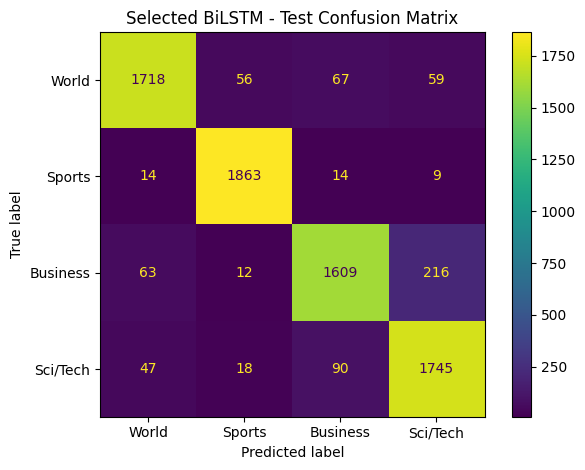

In [ ]:
# Selected BiLSTM confusion matrix.
bilstm_cm = confusion_matrix(
    test_df["Label"],
    bilstm_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=bilstm_cm,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("Selected BiLSTM - Test Confusion Matrix")
plt.tight_layout()
plt.show()


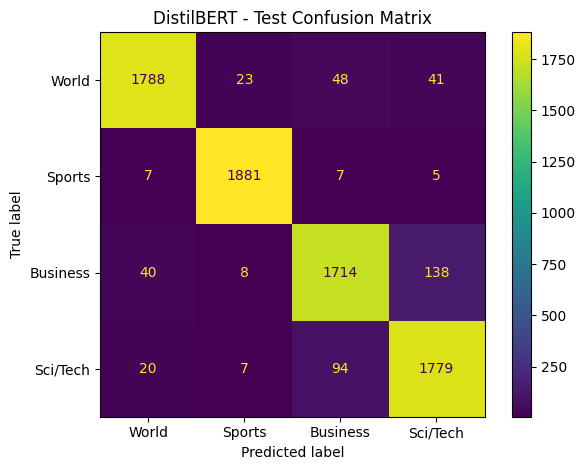

In [ ]:
# DistilBERT confusion matrix.
distilbert_cm = confusion_matrix(
    test_df["Label"],
    distilbert_test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=distilbert_cm,
    display_labels=CLASS_NAMES
)

disp.plot(values_format="d")
plt.title("DistilBERT - Test Confusion Matrix")
plt.tight_layout()
plt.show()


The confusion matrices show that both models classify Sports particularly well, while most of the remaining errors involve categories with greater topical overlap.

The strongest shared pattern is confusion between **Business and Sci/Tech**. DistilBERT produces a cleaner diagonal overall, which is consistent with its higher test accuracy, but the same Business/Sci-Tech boundary remains visible in both models.


### 7.7 Most Common Misclassifications

The largest off-diagonal counts are extracted from each confusion matrix so that the main error patterns can be compared directly.


In [ ]:
def top_misclassifications(cm, labels, top_n=6):
    rows = []

    for true_index in range(len(labels)):
        for predicted_index in range(len(labels)):
            if true_index == predicted_index:
                continue

            count = int(
                cm[true_index, predicted_index]
            )

            if count > 0:
                rows.append({
                    "True Class": labels[true_index],
                    "Predicted Class": labels[predicted_index],
                    "Number of Articles": count
                })

    return (
        pd.DataFrame(rows)
        .sort_values(
            "Number of Articles",
            ascending=False
        )
        .head(top_n)
        .reset_index(drop=True)
    )


print("Selected BiLSTM - Most Common Misclassifications")
display(
    top_misclassifications(
        bilstm_cm,
        CLASS_NAMES
    )
)

print("DistilBERT - Most Common Misclassifications")
display(
    top_misclassifications(
        distilbert_cm,
        CLASS_NAMES
    )
)


Selected BiLSTM - Most Common Misclassifications


,True Class,Predicted Class,Number of Articles
0,Business,Sci/Tech,216
1,Sci/Tech,Business,90
2,World,Business,67
3,Business,World,63
4,World,Sci/Tech,59
5,World,Sports,56


DistilBERT - Most Common Misclassifications


,True Class,Predicted Class,Number of Articles
0,Business,Sci/Tech,138
1,Sci/Tech,Business,94
2,World,Business,48
3,World,Sci/Tech,41
4,Business,World,40
5,World,Sports,23


The most common error for both models is **Business → Sci/Tech**. The BiLSTM makes this error for **216 articles**, while DistilBERT reduces it to **138**, a reduction of 78 cases.

Other BiLSTM errors are also reduced, including World → Business from 67 to 48 and World → Sports from 56 to 23.

Not every individual error direction improves. **Sci/Tech → Business** increases slightly from 90 cases for the BiLSTM to 94 for DistilBERT. This is useful because it shows that the stronger overall model still has a specific area where the class boundary remains difficult.


### 7.8 Qualitative Error Analysis

Several test articles are shown where the BiLSTM is incorrect but DistilBERT predicts the dataset label correctly.

The examples are ranked by the BiLSTM's confidence in its incorrect prediction. This makes it possible to inspect cases where the recurrent model is not merely uncertain, but strongly committed to the wrong class.


In [ ]:
# Show several cases where BiLSTM is wrong but DistilBERT is correct.
true_labels = test_df["Label"].to_numpy()

bilstm_confidence = np.max(
    bilstm_test_probabilities,
    axis=1
)

distilbert_confidence = np.max(
    distilbert_test_probabilities,
    axis=1
)

error_analysis = pd.DataFrame({
    "Title": test_df["Title"].values,
    "True": [
        CLASS_NAMES[i]
        for i in true_labels
    ],
    "BiLSTM Prediction": [
        CLASS_NAMES[i]
        for i in bilstm_test_predictions
    ],
    "BiLSTM Confidence": bilstm_confidence,
    "DistilBERT Prediction": [
        CLASS_NAMES[i]
        for i in distilbert_test_predictions
    ],
    "DistilBERT Confidence": distilbert_confidence
})

bilstm_wrong_bert_correct = error_analysis[
    (bilstm_test_predictions != true_labels)
    & (distilbert_test_predictions == true_labels)
].copy()

bilstm_wrong_bert_correct = (
    bilstm_wrong_bert_correct
    .sort_values(
        "BiLSTM Confidence",
        ascending=False
    )
    .head(8)
)

display(
    bilstm_wrong_bert_correct.round({
        "BiLSTM Confidence": 4,
        "DistilBERT Confidence": 4
    })
)


,Title,True,BiLSTM Prediction,BiLSTM Confidence,DistilBERT Prediction,DistilBERT Confidence
2591,Sports Court Hears Hamm Gold Medal Appeal,World,Sports,0.9987,World,0.9964
3805,"Munro, Morris Face Off in NLCS Game 2",World,Sports,0.9987,World,0.9966
3563,"Ken Caminiti, 1996 NL MVP, Dies at Age 41",World,Sports,0.9986,World,0.9957
2656,Cowboys Defeat Redskins 21-18,World,Sports,0.9958,World,0.9973
5873,Spanish teenager pleads guilty in first trial ...,World,Sports,0.9928,World,0.9852
6794,HAYLEY MICK:,World,Sports,0.9917,World,0.6726
1080,Davenport Advances at U.S. Open,World,Sports,0.9916,World,0.9971
584,Jones Advances in Long Jump; Johnson Out,World,Sports,0.9877,World,0.9962


The displayed examples are especially informative because the BiLSTM is highly confident despite being wrong.

All eight examples shown are labelled **World**, but their titles contain strong sports-related cues such as “Gold Medal”, “NLCS”, “Cowboys”, “U.S. Open” and “Long Jump”. The BiLSTM predicts Sports with confidence between approximately **0.988 and 0.999**.

DistilBERT predicts the dataset's World label correctly for all eight examples. Since both models receive the combined title and description, these cases suggest that the BiLSTM is more easily dominated by obvious topic words, while DistilBERT is better able to use the wider article context when the title alone is misleading.


### 7.9 Final Discussion and Trade-offs

The final results show that both models perform well above the 25% reference baselines, but DistilBERT provides the stronger overall result.

The selected BiLSTM achieves **91.25% test accuracy**, **0.2568 test loss** and a **0.9122 macro F1-score**. DistilBERT reaches **94.24% test accuracy**, **0.1681 test loss** and a **0.9424 macro F1-score**. This is an improvement of **2.99 percentage points in accuracy** and about **0.0302 in macro F1**.

The BiLSTM development also provides an important model-selection result. The baseline reaches its best validation loss of **0.2454 at epoch 2**, after which the training and validation curves clearly diverge. Adding Dropout, ReLU and validation-based callbacks controls the length of training, but the second configuration does not improve the best validation result: its best validation loss is **0.2523**. The original baseline checkpoint is therefore selected rather than assuming that the more regularised model must be better.

DistilBERT's advantage is consistent across all four categories. Its F1-score improves over the BiLSTM by **0.0341 for World**, **0.0170 for Sports**, **0.0365 for Business** and **0.0328 for Sci/Tech**. The largest gain is in Business, while Sports is already very strong for both models.

The main remaining difficulty for both models is the boundary between **Business and Sci/Tech**. The BiLSTM misclassifies 216 Business articles as Sci/Tech, while DistilBERT reduces this to 138. However, DistilBERT slightly increases the reverse Sci/Tech → Business error from 90 to 94 articles. This shows that the stronger model reduces the overall overlap without eliminating it completely.

The qualitative examples also reveal a useful difference between the models. Several articles labelled World have titles containing strong sports-related cues, and the BiLSTM predicts Sports with confidence above 0.98. Because the model input includes both title and description, DistilBERT's correct predictions on these cases suggest that its contextual representations are better able to use the broader article information instead of relying too heavily on obvious topic words.

The stronger performance comes with a clear complexity trade-off. The BiLSTM contains **1,387,332 parameters**, while DistilBERT contains **66,956,548**, making DistilBERT about **48.3 times larger**. The BiLSTM is therefore much more compact and still achieves above 91% test accuracy, while DistilBERT is preferable when the additional model size is acceptable and the highest classification performance is the priority.

The validation-to-test changes are small for both models: the BiLSTM moves from 91.58% validation accuracy to 91.25% test accuracy, while DistilBERT moves from 94.59% to 94.24%. This close agreement supports the validation-based model-selection process and suggests that both final results generalise well to unseen articles.

Future improvements should focus on the remaining Business/Sci-Tech overlap rather than simply adding more training epochs. Useful experiments could include testing a small range of fine-tuning learning rates, examining the most ambiguous Business/Sci-Tech articles in more detail, and comparing DistilBERT with another compact pretrained transformer. Any further tuning should continue to use validation data, with the official test set reserved for final evaluation.


## References

[1] Kaggle. **AG News Classification Dataset**.  
https://www.kaggle.com/datasets/amananandrai/ag-news-classification-dataset

[2] UpGrad. **Deep Learning vs NLP: Difference Between Deep Learning & NLP**.  
https://www.upgrad.com/blog/deep-learning-vs-nlp/

[3] Scikit-learn. **CountVectorizer**. Scikit-learn Documentation.  
https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

[4] NLTK. **Natural Language Processing with Python – Processing Raw Text**.  
https://www.nltk.org/book/ch03.html

[5] TensorFlow. **tf.keras.layers.TextVectorization**. TensorFlow API Documentation.  
https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization

[6] Keras. **Embedding Layer**. Keras API Documentation.  
https://keras.io/api/layers/core_layers/embedding/

[7] Hugging Face. **DistilBERT**. Transformers Documentation.  
https://huggingface.co/docs/transformers/model_doc/distilbert

[8] IT3381 Applied Deep Learning lecture materials

[9] IT3381 Applied Deep Learning module notebooks
